# Sensitive nodes in the GA-evolved k=8 sensor set vs noise (rho)

For each network we take the genetic algorithm's evolved **k=8** feature set
(`max_num_features=8`, final generation) and ask how many of those 8 nodes are
actually **sensitive** to drug perturbation, then average that count over the 50
networks and plot it against the network noise level `rho`.

**Sensitivity metric** — the per-node Hamming distance from control:

```
B[network][node] = mean_{drug, ic, step} |state_drug(node) - state_control(node)|
```

States are aligned by `(initial_condition_idx, step_num)` before subtraction, mean
over those pairs, then mean over the 10 drugs (matches
`node-drug-sensitivity.ipynb` / `hamming-distance-vs-control-plot.py`).

A node counts as sensitive two ways (both shown): a **fixed** cutoff
(`B > 0.0815`, from the hamming-distance script) and a per-rho **relative** cutoff
(`mean + 2*std` of B over all nodes at that rho), since a fixed cutoff inflates
as noise raises the baseline. We also plot the raw mean sensitivity value.

rho values available now: **0.5** (v7) and **0.99** (v5). rho=0.75 is deferred
(needs a full new sim -> extract -> GA pipeline).

## Outputs
- `data/sensitivity/B-rho{rho}.npz` — cached per-node sensitivity matrix (50 x N).
- `data/sensitivity/sensitive-nodes-vs-rho.csv` — per-network sensitive counts.
- `plots/sensitive-nodes-vs-rho.png` — the figure.

## Section 0: Setup & config

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

N = 5000
K = 8
FIXED_CUTOFF = 0.0815
OUT_DIR = '../data/sensitivity'
os.makedirs(OUT_DIR, exist_ok=True)

# rho -> (states csv, ga combined csv). Both already on disk.
DATASETS = {
  0.5: {
    'states': '../data/drug-fixed-targets-v7/N5000/derived/states-1772488362007.csv',
    'ga': '../data/drug-fixed-targets-v7/N5000/ga-results-v7/combined-full.csv',
  },
  0.99: {
    'states': '../data/drug-fixed-targets-v5/N5000/derived/states-1771990942417.csv',
    'ga': '../data/drug-fixed-targets-v5/N5000/ga-results-v5/combined-full.csv',
  },
}
print(f'rho values: {sorted(DATASETS)}')

rho values: [0.5, 0.99]


## Section 1: Compute (and cache) the per-node sensitivity matrix B

Heavy step — reads the multi-GB states CSV once per rho, then caches `B` to
`.npz` so re-runs are instant. Delete the `.npz` to force recompute.

In [3]:
def compute_B(states_csv, n):
  '''Per-node Hamming distance from control: B[network, node] in [0, 1].'''
  node_cols = [f'node-{i}' for i in range(n)]
  df = pd.read_csv(states_csv)
  networks = sorted(df['original_network_idx'].unique())
  drugs = sorted(
    [d for d in df['drug_name'].unique() if d != 'control'],
    key=lambda x: int(x.split('-')[1]),
  )
  B = np.zeros((len(networks), n), dtype=np.float64)
  for row, net in enumerate(networks):
    df_net = df[df['original_network_idx'] == net]
    ctrl = (
      df_net[df_net['drug_name'] == 'control']
      .set_index(['initial_condition_idx', 'step_num'])[node_cols]
      .astype(np.float64)
      .sort_index()
    )
    acc = np.zeros(n, dtype=np.float64)
    for drug in drugs:
      treated = (
        df_net[df_net['drug_name'] == drug]
        .set_index(['initial_condition_idx', 'step_num'])[node_cols]
        .astype(np.float64)
        .sort_index()
      )
      assert treated.shape == ctrl.shape, f'shape mismatch net={net} drug={drug}'
      acc += np.abs(treated.to_numpy() - ctrl.to_numpy()).mean(axis=0)
    B[row] = acc / len(drugs)
  return B, np.array(networks)


B_by_rho = {}
networks_by_rho = {}
for rho, paths in DATASETS.items():
  cache = f'{OUT_DIR}/B-rho{rho}.npz'
  if os.path.exists(cache):
    print(f'rho={rho}: loading cached {cache}')
    data = np.load(cache)
    B_by_rho[rho] = data['B']
    networks_by_rho[rho] = data['networks']
  else:
    print(f'rho={rho}: computing B from {paths["states"]} (large read)...')
    B, nets = compute_B(paths['states'], N)
    np.savez_compressed(cache, B=B, networks=nets)
    B_by_rho[rho] = B
    networks_by_rho[rho] = nets
    print(f'  saved {cache}')
  B = B_by_rho[rho]
  print(f'  B shape={B.shape}  min={B.min():.4f}  max={B.max():.4f}  mean={B.mean():.4f}')

rho=0.5: loading cached ../data/sensitivity/B-rho0.5.npz
  B shape=(50, 5000)  min=0.0000  max=0.9240  mean=0.1829
rho=0.99: loading cached ../data/sensitivity/B-rho0.99.npz
  B shape=(50, 5000)  min=0.0000  max=0.8240  mean=0.1780


## Section 2: Load the GA-evolved k=8 subsets

For each network take the final-generation row at `max_num_features=8` and parse
its `features` set into node indices.

In [4]:
def load_ga_subset(ga_csv, k):
  '''network idx -> list of k node indices (GA best, final generation).'''
  ga = pd.read_csv(ga_csv)
  ga = ga[ga['max_num_features'] == k]
  final_idx = ga.groupby('original_network_idx')['generation'].idxmax()
  final = ga.loc[final_idx]
  subsets = {}
  for _, r in final.iterrows():
    nodes = [int(s.split('-')[1]) for s in eval(r['features'])]
    subsets[int(r['original_network_idx'])] = nodes
  return subsets


subsets_by_rho = {rho: load_ga_subset(p['ga'], K) for rho, p in DATASETS.items()}
for rho, s in subsets_by_rho.items():
  sizes = sorted({len(v) for v in s.values()})
  print(f'rho={rho}: {len(s)} networks, subset sizes={sizes}')

rho=0.5: 50 networks, subset sizes=[8]
rho=0.99: 50 networks, subset sizes=[6, 7, 8]


## Section 3: Build & save the sensitivity table

For each rho x network: how many of the 8 GA-selected nodes are sensitive
(fixed & relative cutoffs), and the mean sensitivity of the subset.

In [5]:
rows = []
rel_cutoffs = {}
for rho in DATASETS:
  B = B_by_rho[rho]
  nets = list(networks_by_rho[rho])
  rel_cutoff = float(B.mean() + 2 * B.std())
  rel_cutoffs[rho] = rel_cutoff
  for net, nodes in subsets_by_rho[rho].items():
    if net not in nets:
      continue
    vals = B[nets.index(net)][nodes]
    rows.append({
      'rho': rho,
      'original_network_idx': net,
      'n_sensitive_fixed': int((vals > FIXED_CUTOFF).sum()),
      'n_sensitive_relative': int((vals > rel_cutoff).sum()),
      'mean_B': float(vals.mean()),
      'rel_cutoff': rel_cutoff,
    })

table = pd.DataFrame(rows)
table.to_csv(f'{OUT_DIR}/sensitive-nodes-vs-rho.csv', index=False)
print(f'saved {OUT_DIR}/sensitive-nodes-vs-rho.csv  shape={table.shape}')
print(f'relative cutoffs per rho: {" ".join(f"{r}={c:.4f}" for r, c in rel_cutoffs.items())}')
print()
print('mean over networks:')
print(table.groupby('rho')[['n_sensitive_fixed', 'n_sensitive_relative', 'mean_B']].mean().round(3))

saved ../data/sensitivity/sensitive-nodes-vs-rho.csv  shape=(100, 6)
relative cutoffs per rho: 0.5=0.5436 0.99=0.5412

mean over networks:
      n_sensitive_fixed  n_sensitive_relative  mean_B
rho                                                  
0.50               7.48                  0.10   0.367
0.99               7.42                  0.22   0.372


## Section 4: Plot — avg # sensitive nodes vs rho

Point estimates with error bars over the 50 networks (out of K=8).

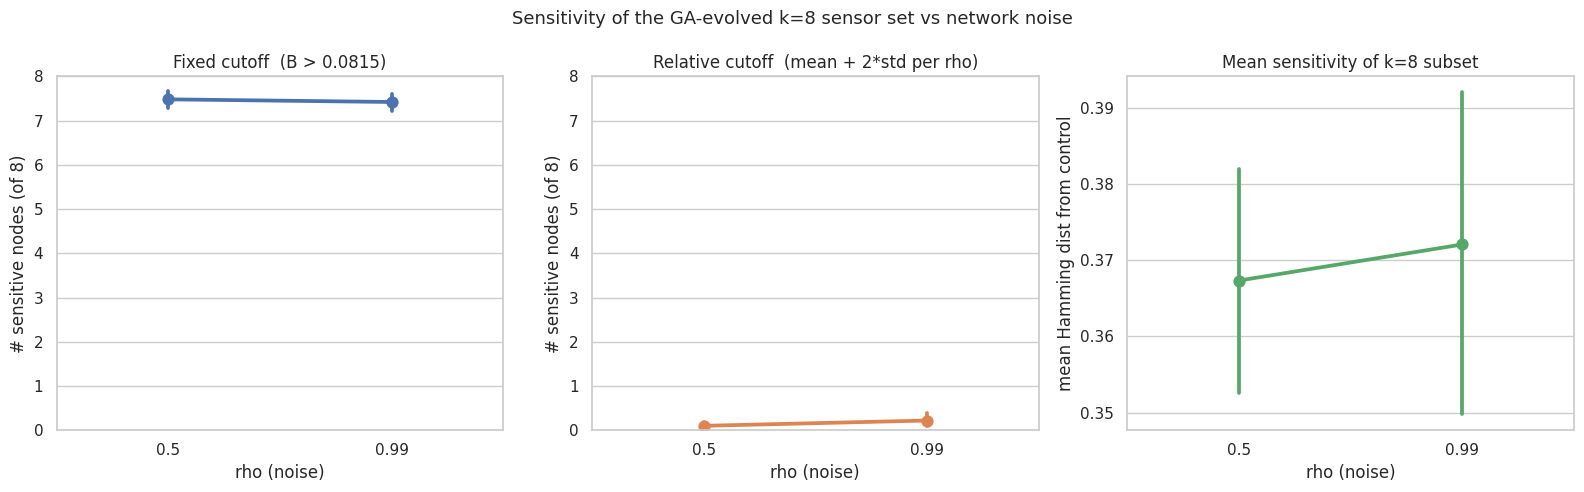

saved -> plots/sensitive-nodes-vs-rho.png


In [6]:
order = sorted(DATASETS)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.pointplot(
  data=table, x='rho', y='n_sensitive_fixed', order=order, ax=axes[0], color='C0',
)
axes[0].set(
  xlabel='rho (noise)', ylabel=f'# sensitive nodes (of {K})',
  title=f'Fixed cutoff  (B > {FIXED_CUTOFF})', ylim=(0, K),
)

sns.pointplot(
  data=table, x='rho', y='n_sensitive_relative', order=order, ax=axes[1], color='C1',
)
axes[1].set(
  xlabel='rho (noise)', ylabel=f'# sensitive nodes (of {K})',
  title='Relative cutoff  (mean + 2*std per rho)', ylim=(0, K),
)

sns.pointplot(
  data=table, x='rho', y='mean_B', order=order, ax=axes[2], color='C2',
)
axes[2].set(
  xlabel='rho (noise)', ylabel='mean Hamming dist from control',
  title='Mean sensitivity of k=8 subset',
)

fig.suptitle('Sensitivity of the GA-evolved k=8 sensor set vs network noise', fontsize=13)
plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/sensitive-nodes-vs-rho.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved -> plots/sensitive-nodes-vs-rho.png')

## Section 5: Sweep subset size k

At k=8 the GA-selected nodes sit near the sensitivity ceiling for both rho, so
the rho effect is hard to see. Sweeping k tests where (if anywhere) noise
matters: as k grows the GA must pad the subset with less-responsive nodes, and
the **fraction** that stay sensitive should fall off faster at high noise if the
pool of genuinely drug-responsive nodes is smaller there.

Reuses the cached B (no CSV re-read). k values are auto-discovered from the GA
results (typically powers of 2 — 5/6/7 usually were not evolved). Note the
relative cutoff (~0.54) sits *above* most selected nodes, so its curves stay low;
`mean_B` and the fixed-cutoff fraction are the more readable panels.

In [7]:
def subset_from_df(ga, k):
  '''network idx -> node indices for the final-generation best set at size k.'''
  g = ga[ga['max_num_features'] == k]
  final_idx = g.groupby('original_network_idx')['generation'].idxmax()
  out = {}
  for _, r in g.loc[final_idx].iterrows():
    out[int(r['original_network_idx'])] = [int(s.split('-')[1]) for s in eval(r['features'])]
  return out


ga_by_rho = {rho: pd.read_csv(p['ga']) for rho, p in DATASETS.items()}
k_values = sorted(set.intersection(*[
  set(ga['max_num_features'].unique()) for ga in ga_by_rho.values()
]))
print(f'available k values (shared across rho): {k_values}')

sweep = []
for rho in DATASETS:
  B = B_by_rho[rho]
  nets = list(networks_by_rho[rho])
  rel_cutoff = rel_cutoffs[rho]
  for k in k_values:
    for net, nodes in subset_from_df(ga_by_rho[rho], k).items():
      if net not in nets:
        continue
      vals = B[nets.index(net)][nodes]
      sweep.append({
        'rho': rho,
        'k': k,
        'original_network_idx': net,
        'frac_sensitive_fixed': float((vals > FIXED_CUTOFF).mean()),
        'frac_sensitive_relative': float((vals > rel_cutoff).mean()),
        'mean_B': float(vals.mean()),
      })

sweep_df = pd.DataFrame(sweep)
sweep_df.to_csv(f'{OUT_DIR}/sensitive-nodes-vs-k.csv', index=False)
print(f'saved {OUT_DIR}/sensitive-nodes-vs-k.csv  shape={sweep_df.shape}')
print()
print(sweep_df.groupby(['rho', 'k'])[['frac_sensitive_fixed', 'mean_B']].mean().round(3))

available k values (shared across rho): [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(5000)]
saved ../data/sensitivity/sensitive-nodes-vs-k.csv  shape=(1400, 6)

           frac_sensitive_fixed  mean_B
rho  k                                 
0.50 1                    0.980   0.338
     2                    1.000   0.413
     4                    0.995   0.415
     8                    0.935   0.367
     16                   0.740   0.263
     32                   0.619   0.207
     64                   0.577   0.188
     128                  0.563   0.183
     256                  0.568   0.182
     512                  0.564   0.182
     1024                 0.568   0.184
     2048                 0.568   0.183
     4096                 0.568   0.183
     5000                 0.568   0.183
0.99 1                    0.960   0.325
     2 

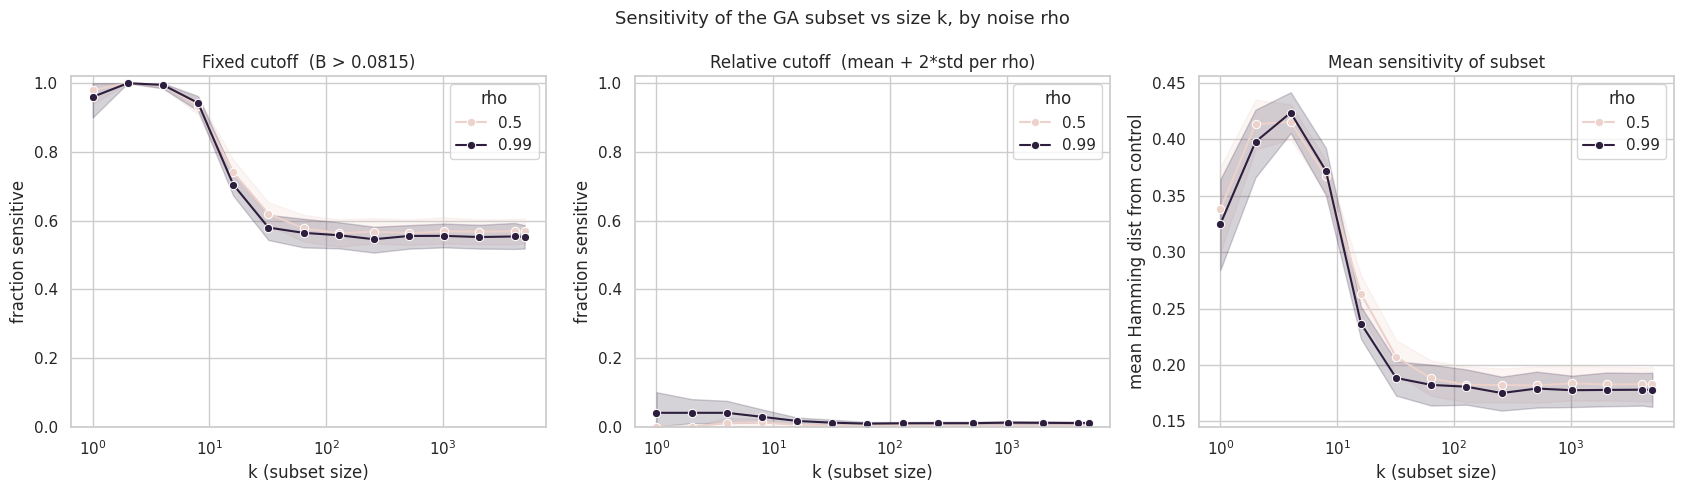

saved -> plots/sensitive-nodes-vs-k.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.lineplot(
  data=sweep_df, x='k', y='frac_sensitive_fixed', hue='rho', marker='o', ax=axes[0],
)
axes[0].set(
  xscale='log', xlabel='k (subset size)', ylabel='fraction sensitive',
  title=f'Fixed cutoff  (B > {FIXED_CUTOFF})', ylim=(0, 1.02),
)

sns.lineplot(
  data=sweep_df, x='k', y='frac_sensitive_relative', hue='rho', marker='o', ax=axes[1],
)
axes[1].set(
  xscale='log', xlabel='k (subset size)', ylabel='fraction sensitive',
  title='Relative cutoff  (mean + 2*std per rho)', ylim=(0, 1.02),
)

sns.lineplot(
  data=sweep_df, x='k', y='mean_B', hue='rho', marker='o', ax=axes[2],
)
axes[2].set(
  xscale='log', xlabel='k (subset size)', ylabel='mean Hamming dist from control',
  title='Mean sensitivity of subset',
)

fig.suptitle('Sensitivity of the GA subset vs size k, by noise rho', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/sensitive-nodes-vs-k.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved -> plots/sensitive-nodes-vs-k.png')

## Section 6: B distribution per rho with candidate cutoffs

Where should the "sensitive" line go? This pools every node's B at each rho
(log-y so the responsive tail is visible) and overlays the candidate cutoffs:
the fixed 0.0815, the per-rho relative mean+2*std (~0.54), the auto-detected
**antimode** (the valley separating the near-zero insensitive spike from the
responsive population), and the GA k=8 subset mean for reference. If the two rho
histograms sit on top of each other, the sensitivity really is noise-invariant
here — and the antimode is the only cutoff that lands in a discriminating spot.

per-rho antimode estimates: [0.355, 0.335]  -> using 0.345


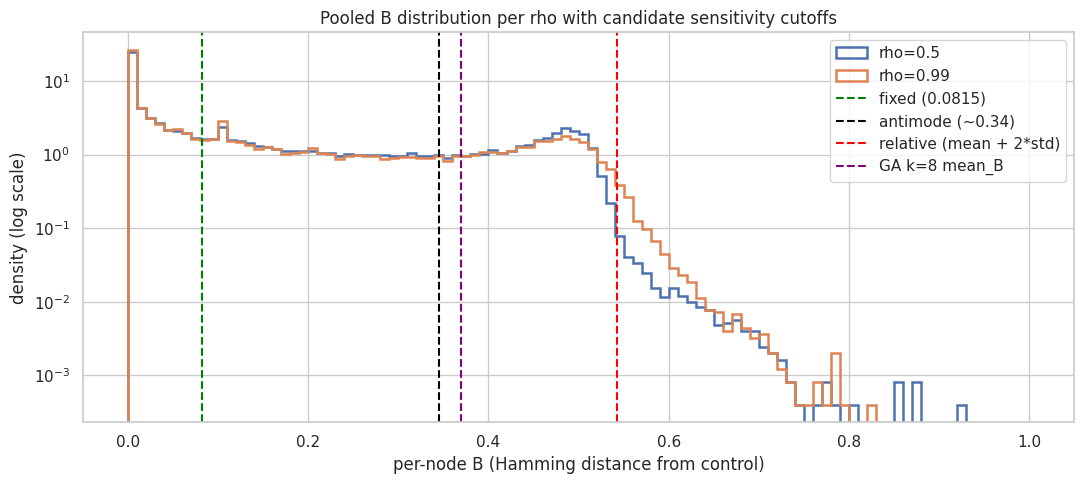

saved -> plots/b-distribution-cutoffs.png


In [9]:
bins = np.linspace(0, 1, 101)

# Auto-detect the antimode (valley) of the pooled B distribution per rho:
# the low point between the near-zero 'insensitive' spike and the responsive tail.
antimodes = {}
for rho in DATASETS:
  counts, edges = np.histogram(B_by_rho[rho].ravel(), bins=bins)
  centers = 0.5 * (edges[:-1] + edges[1:])
  smooth = np.convolve(counts, np.ones(5) / 5, mode='same')
  window = (centers > 0.05) & (centers < 0.40)
  antimodes[rho] = float(centers[window][np.argmin(smooth[window])])
antimode = float(np.mean(list(antimodes.values())))
print(f'per-rho antimode estimates: {[round(v, 3) for v in antimodes.values()]}  -> using {antimode:.3f}')

cutoffs = [
  (FIXED_CUTOFF, 'green', f'fixed ({FIXED_CUTOFF})'),
  (antimode, 'black', f'antimode (~{antimode:.2f})'),
  (float(np.mean(list(rel_cutoffs.values()))), 'red', 'relative (mean + 2*std)'),
  (float(table['mean_B'].mean()), 'purple', 'GA k=8 mean_B'),
]

fig, ax = plt.subplots(figsize=(11, 5))
for rho, color in zip(DATASETS, ['C0', 'C1']):
  ax.hist(
    B_by_rho[rho].ravel(), bins=bins, density=True, histtype='step',
    color=color, linewidth=1.8, label=f'rho={rho}',
  )
ax.set_yscale('log')
for x, color, label in cutoffs:
  ax.axvline(x, color=color, linestyle='--', linewidth=1.5, label=label)

ax.set(
  xlabel='per-node B (Hamming distance from control)', ylabel='density (log scale)',
  title='Pooled B distribution per rho with candidate sensitivity cutoffs',
)
ax.legend()
plt.tight_layout()
plt.savefig('../plots/b-distribution-cutoffs.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved -> plots/b-distribution-cutoffs.png')

## Section 7: Node-ablation — does accuracy actually depend on the sensitive nodes?

The 'backwards' knockout view. For each network's **exactly-8** evolved set we
remove m = 1, 2, 3 nodes, retrain the GA's own RandomForest evaluator
(`scripts/classifier.py`), and record the accuracy drop against how many of the
removed nodes were sensitive (B > antimode). This says something stronger than
forward selection: many k-subsets classify well, so what matters is whether
accuracy *collapses* specifically when the sensitive nodes are pulled.

Heavy compute lives in a script (reuses the exact GA fitness, matches
`best_accuracy`). Run it first from the repo root in the venv:

```
python scripts/node-ablation-k8.py --rho 0.5
python scripts/node-ablation-k8.py --rho 0.99
```

It writes `data/sensitivity/ablation-k8-rho{rho}.csv`; the cell below loads and
plots them. **Note:** it uses only networks whose evolved set is *exactly* 8
nodes — rho=0.5 keeps all 50, rho=0.99 keeps fewer (the older v5 GA sometimes
returned 6–7). To force all 50 at exactly 8, re-run the GA with
`--feature-sizes 8` (the current GA fills back up to k).

In [ ]:
import glob

abl_files = sorted(glob.glob(f'{OUT_DIR}/ablation-k8-rho*.csv'))
if not abl_files:
  print('No ablation CSVs yet. Run (from repo root, in the venv):')
  print('  python scripts/node-ablation-k8.py --rho 0.5')
  print('  python scripts/node-ablation-k8.py --rho 0.99')
else:
  abl = pd.concat([pd.read_csv(f) for f in abl_files], ignore_index=True)
  print(f'loaded {len(abl)} ablation rows from {len(abl_files)} file(s)')
  print()
  print('mean accuracy drop by rho, m, and # sensitive removed:')
  print(abl.groupby(['rho', 'm_removed', 'n_sensitive_removed'])['acc_drop']
           .agg(['mean', 'count']).round(3))

  m_values = sorted(abl['m_removed'].unique())
  fig, axes = plt.subplots(1, len(m_values), figsize=(6 * len(m_values), 5), sharey=True)
  if len(m_values) == 1:
    axes = [axes]
  for ax, m in zip(axes, m_values):
    sns.pointplot(
      data=abl[abl['m_removed'] == m], x='n_sensitive_removed', y='acc_drop',
      hue='rho', dodge=0.3, ax=ax,
    )
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set(
      xlabel='# sensitive nodes removed', ylabel='accuracy drop (baseline - ablated)',
      title=f'Remove m = {m} of {K}',
    )

  fig.suptitle('Accuracy drop when removing sensitive vs insensitive nodes from the k=8 set', fontsize=13)
  plt.tight_layout()
  plt.savefig('../plots/ablation-k8-acc-drop.png', dpi=200, bbox_inches='tight')
  plt.show()
  print('saved -> plots/ablation-k8-acc-drop.png')